## Setup and Imports

Import required libraries for statistical modeling, numerical computation, and visualization.

In [1]:
import numpy as np
from scipy.special import gammaln
from scipy.stats import norm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)

# Fisher Scoring Algorithm Functions 


**Core Algorithm Implementation**

Implements Fisher Scoring for GLMs (logistic and Poisson regression):
- `compute_mu`: Link function to compute mean
- `gradient`: Score function for parameter updates
- `fisher_information`: Expected information matrix
- `log_lik`: Log-likelihood function
- `fisher_scoring`: Main iterative algorithm
- `fisher_results`: Statistical inference (standard errors, z-scores, p-values)

In [2]:

def compute_mu(eta, link='logistic'):
    if link == 'logistic':
        return 1 / (1 + np.exp(-eta))
    elif link == 'poisson':
        return np.exp(eta)


def gradient(beta, X, Y, link='logistic'):
    eta = X @ beta
    mu = compute_mu(eta, link=link)
    grad = X.T @ (Y - mu)
    return grad 
 
def fisher_information(beta, X, link='logistic'):
    eta = X @ beta
    mu = compute_mu(eta, link=link)

    if link == 'logistic':
        w = mu * (1 - mu)
        w = np.clip(w, 1e-12, np.inf)
    elif link == 'poisson':
        w = np.clip(mu, 1e-12, np.inf)

    W = np.diag(w) 
    I_beta = X.T @ W @ X 
    return I_beta 

def log_lik(beta, X, Y, link='logistic'):
    eta = X @ beta
    mu = compute_mu(eta, link=link)

    if link == 'logistic':
        eps = 1e-12
        mu = np.clip(mu, eps, 1 - eps)
        ell = np.sum(Y * np.log(mu) + (1 - Y) * np.log(1 - mu))
        return ell
    elif link == 'poisson':
        eps = 1e-12
        mu = np.clip(mu, eps, np.inf)
        ell = np.sum(Y * np.log(mu) - mu - gammaln(Y + 1))
        return ell 
    
def fisher_scoring(X, Y, max_iter=100, eps=1e-8, link='logistic',
                   ridge=0.0):
    n, p = X.shape
    beta = np.zeros(p)

    history = {'beta': [beta.copy()],
               'log_lik': [log_lik(beta, X, Y, link)],
               'grad_norm': []}

    for it in range(max_iter):
        grad = gradient(beta, X, Y, link)
        grad_norm = np.linalg.norm(grad)
        history['grad_norm'].append(grad_norm)

        if grad_norm < eps:
            print(f"Converged at iteration {it}")
            break

        I = fisher_information(beta, X, link)
        I_reg = I + ridge * np.eye(p)

        try:
            delta = np.linalg.solve(I_reg, grad)
        except np.linalg.LinAlgError:
            print('Error')
            break

        
        beta = beta + delta 
        history['beta'].append(beta.copy())
        history['log_lik'].append(log_lik(beta, X, Y, link))

    return beta, history

def fisher_results(beta, X, link='logistic', ridge=0.0):
    I = fisher_information(beta, X, link) + ridge * np.eye(X.shape[1])
    cov = np.linalg.inv(I)
    se = np.sqrt(np.diag(cov))
    z = beta / se
    p = 2 * (1 - norm.cdf(np.abs(z)))
    return se, z, p

**Helper Functions**

Utility function to add significance stars based on p-values.

In [3]:
def add_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

**Visualization Functions**

Functions to display and plot Fisher Scoring results:
- `display_fisher_results`: Format coefficient table with statistical significance
- `plot_fisher_convergence`: Visualize algorithm convergence via log-likelihood and gradient norm

In [4]:
def display_fisher_results(beta, X, Y, feature_names, link_type, title=None):
    se, z_val, p_val = fisher_results(beta,X, link=link_type)

    results_df = pd.DataFrame({'Variable': feature_names,
                               'Coefficient': beta,
                               'Std Error': se,
                               'z-value': z_val,
                               'p-value': p_val})

    results_df['Signif.'] = results_df['p-value'].apply(add_stars)

    if title is None:
        if link_type == 'logistic':
            title = "Fisher Scoring Results - Logistic Regression"
        elif link_type == 'poisson':
            title = "Fisher Scoring Results - Poisson Regression"
        else:
            title = "Fisher Scoring Results"

    print(title)
    print(results_df)
    return results_df


def plot_fisher_convergence(history, title=None, figsize=(14, 5)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    if title is None:
        title = "Fisher Scoring"

    # Log-likelihood plot
    axes[0].plot(history['log_lik'], 'b-')
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Log-Likelihood')
    axes[0].set_title(f'{title}: Log-Likelihood Convergence')
    axes[0].grid(True, alpha=0.3)

    # Gradient norm plot
    axes[1].plot(history['grad_norm'], 'r-')
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('||Gradient||')
    axes[1].set_title(f'{title}: Gradient Norm')
    axes[1].set_yscale('log')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# MCMC Functions 

**Bayesian framework functions:**
- `log_prior_normal`: Normal prior on coefficients
- `log_post`: Log-posterior (prior + likelihood)

In [5]:
def log_prior_normal(beta, sigma2=10.0):
    return -0.5 * np.linalg.norm(beta)**2 / sigma2

def log_post(beta, X, Y, sigma2=10.0, link = 'logistic'):
    log_prior = log_prior_normal(beta, sigma2)
    log_likelihood = log_lik(beta, X, Y, link)
    return log_prior + log_likelihood

**Metropolis-Hastings MCMC**

Implements Metropolis-Hastings algorithm with:
- Random walk proposals
- Burn-in period
- Thinning for reduced autocorrelation
- Acceptance rate tracking

In [6]:
def mh(X, Y, n_iter=10000, burn_in=1000, rw_sd=0.05,
                sigma2=10.0, init_beta=None, thin=10, link = 'logistic'):
    n, p = X.shape

    if init_beta is None:
        beta_curr = np.zeros(p)
    else:
        beta_curr = init_beta.copy()

    n_saved = (n_iter - burn_in) // thin
    beta_samples = np.zeros((n_saved, p))
    log_post_samples = np.zeros(n_saved)
    accept_count = 0

    sample_idx = 0

    for iteration in range(n_iter):
        log_post_curr = log_post(beta_curr, X, Y, sigma2, link)
        beta_proposed = beta_curr + np.random.normal(0, rw_sd, size=p)
        log_post_proposed = log_post(beta_proposed, X, Y, sigma2, link)
        log_alpha = log_post_proposed - log_post_curr

        if np.log(np.random.rand()) < log_alpha:
            beta_curr = beta_proposed
            accept_count += 1

        if iteration >= burn_in and (iteration - burn_in) % thin == 0:
            beta_samples[sample_idx] = beta_curr
            log_post_samples[sample_idx] = log_post_curr
            sample_idx += 1

    accept_rate = accept_count / n_iter

    samples = {'beta': beta_samples,
               'log_posterior': log_post_samples}

    return samples, accept_rate

**MCMC Summary Statistics**

Computes posterior summaries: mean, median, standard deviation, and 95% credible intervals.

In [7]:
def mcmc_summary(mcmc_samples, feature_names):
    beta_mean = np.mean(mcmc_samples['beta'], axis=0)
    beta_median = np.median(mcmc_samples['beta'], axis=0)
    beta_std = np.std(mcmc_samples['beta'], axis=0)
    beta_q025 = np.percentile(mcmc_samples['beta'], 2.5, axis=0)
    beta_q975 = np.percentile(mcmc_samples['beta'], 97.5, axis=0)

    mcmc_summary_df = pd.DataFrame({'Variable': feature_names,
                                    'Mean': beta_mean,
                                    'Median': beta_median,
                                    'Std Dev': beta_std,
                                    '2.5%': beta_q025,
                                    '97.5%': beta_q975})

    return mcmc_summary_df

**MCMC Diagnostics**

Comprehensive MCMC diagnostics including:
- Trace plots for chain convergence
- Posterior distributions
- Autocorrelation function (ACF) for chain mixing
- Comparison with Fisher Scoring estimates

In [8]:
def compute_acf(x, max_lag):
    x = x - np.mean(x)
    c0 = np.dot(x, x) / len(x)
    acf = np.array([np.dot(x[lag:], x[:-lag if lag > 0 else None]) / len(x) / c0 for lag in range(max_lag + 1)])
    return acf

def mcmc_trace_acf(mcmc_samples, feature_names, variable_name, beta_fisher=None, max_lag=50):
    """
    Plot trace plot and ACF plot side by side (1x2 subplots)
    """
    var_idx = feature_names.index(variable_name)
    acf_values = compute_acf(mcmc_samples['beta'][:, var_idx], max_lag=max_lag)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Trace plot
    axes[0].plot(mcmc_samples['beta'][:, var_idx], linewidth=0.5, alpha=0.7)
    if beta_fisher is not None:
        axes[0].axhline(beta_fisher[var_idx], color='r', linestyle='--', label='Fisher Scoring')
    axes[0].set_title(f"Trace Plot: β_{variable_name}")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("β")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Autocorrelation plot
    axes[1].bar(range(len(acf_values)), acf_values, width=0.35)
    axes[1].axhline(0, color='k', linewidth=0.8)
    # 95% confidence bands
    axes[1].axhline(1.96/np.sqrt(len(mcmc_samples['beta'])), color='r', linestyle='--',
                label='95% CI')
    axes[1].axhline(-1.96/np.sqrt(len(mcmc_samples['beta'])), color='r', linestyle='--')
    axes[1].set_title("Autocorrelation")
    axes[1].set_xlabel("Lag")
    axes[1].set_ylabel("ACF")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'mcmc_trace_acf_{variable_name}.png')
    plt.show()

def mcmc_posterior(mcmc_samples, feature_names, variable_name, beta_fisher=None):
    """
    Plot posterior distribution
    """
    var_idx = feature_names.index(variable_name)
    beta_mean = np.mean(mcmc_samples['beta'][:, var_idx])

    fig, ax = plt.subplots(figsize=(8, 5))

    # Posterior distribution
    ax.hist(mcmc_samples['beta'][:, var_idx],
             bins=50, density=True, alpha=0.7, edgecolor='black')
    if beta_fisher is not None:
        ax.axvline(beta_fisher[var_idx],
                    color='r', linestyle='--', linewidth=2, label='Fisher Scoring')
    ax.axvline(beta_mean,
                color='g', linestyle='-', linewidth=2, label='MCMC Mean')
    ax.set_title(f"Posterior Distribution: β_{variable_name}")
    ax.set_xlabel(f"β_{variable_name}")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(f'mcmc_posterior_{variable_name}.png')
    plt.show()

**Method Comparison Visualization**

Plots coefficients from Fisher Scoring (frequentist) vs MCMC (Bayesian) with confidence/credible intervals.

In [9]:
def plot_coefficient_comparison(fisher_results_df, mcmc_summary_df,
                                title="Comparison of Coefficient Estimates",
                                figsize=(10, 8)):

    fig, ax = plt.subplots(figsize=figsize)

    vars_to_plot = mcmc_summary_df['Variable'].values[1:]

    fisher_coefs = fisher_results_df['Coefficient'].values[1:]
    fisher_se = fisher_results_df['Std Error'].values[1:]

    mcmc_means = mcmc_summary_df['Mean'].values[1:]
    mcmc_q025 = mcmc_summary_df['2.5%'].values[1:]
    mcmc_q975 = mcmc_summary_df['97.5%'].values[1:]

    y_pos = np.arange(len(vars_to_plot))

    # Plot Fisher Scoring estimates
    ax.errorbar(fisher_coefs, y_pos - 0.15, xerr=1.96*fisher_se, fmt='o',
                color='red', ecolor='red', capsize=5, capthick=2,
                label='Fisher Scoring (95% CI)', markersize=8)

    # Plot MCMC estimates
    for i in range(len(vars_to_plot)):
        ax.plot([mcmc_q025[i], mcmc_q975[i]], [y_pos[i] + 0.15, y_pos[i] + 0.15],
                'b-', linewidth=2)
    ax.plot(mcmc_means, y_pos + 0.15, 'bo', label='MCMC (95% Credible Interval)', markersize=8)

    ax.axvline(x=0, color='k', linestyle='--', linewidth=1, alpha=0.5)

    # Formatting
    ax.set_yticks(y_pos)
    ax.set_yticklabels(vars_to_plot)
    ax.set_xlabel('Coefficient Estimate', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()

    return fig, ax

**Covariate Interpretation**

Identifies top influential predictors and provides interpretable effect sizes (exponential of coefficients).

In [22]:
def top_influential_covariates(beta, feature_names, std_dict, top_k=3):
    beta_no_intercept = beta[1:]
    names_no_intercept = feature_names[1:]

    top_idx = np.argsort(np.abs(beta_no_intercept))[::-1][:top_k]

    rows = []
    for idx in top_idx:
        var_name = names_no_intercept[idx]
        coef_std = beta_no_intercept[idx]
        sigma_x = std_dict.get(var_name, 1.0) 
        coef_raw = coef_std / sigma_x
        
        effect_raw = np.exp(coef_raw)

        if coef_raw > 0:
            percentage = (effect_raw - 1) * 100
            interpretation = f"increases the mean/odds by {percentage:.2f}%"
        else:
            percentage = (1 - effect_raw) * 100
            interpretation = f"decreases the mean/odds by {percentage:.2f}%"

        rows.append([
            var_name, 
            f"{coef_std:.4f} (std)", 
            f"{coef_raw:.4f} (raw)", 
            f"{effect_raw:.4f}", 
            interpretation
        ])

    return pd.DataFrame(rows, columns=["Variable", "Coef(Std)", "Coef(Raw)", "exp(Coef_Raw)", "Interpretation"])

# CREDIT CARD DATASET 


## Fisher scoring Run 

**Data Preprocessing**

Load credit card dataset and:
- Convert categorical variables to binary
- Standardize continuous features (zero mean, unit variance)
- Add intercept column

In [11]:
data = pd.read_csv('CreditCard.csv')

print("Dataset shape:", data.shape)

data['card'] = (data['card'] == 'yes').astype(int)
data['owner'] = (data['owner'] == 'yes').astype(int)
data['selfemp'] = (data['selfemp'] == 'yes').astype(int)

data = data.drop(['share', 'expenditure'], axis=1)

Y = data['card'].values
X = data.drop('card', axis=1)

binary_cols = ['owner', 'selfemp']   
continuous_cols = [c for c in X.columns if c not in binary_cols]


# Standardization
X_norm = X.copy()

for col in continuous_cols:
    mean = X_norm[col].mean()
    std = X_norm[col].std(ddof=1)
    X_norm[col] = (X_norm[col] - mean) / std


X_scaled = np.column_stack([np.ones(len(X_norm)), X_norm.values])

feature_names = ['Intercept'] + [col for col in data.columns if col != 'card']


Dataset shape: (1319, 12)


In [12]:
print("--- Credit Card Dataset Std ---")
print(data.std(ddof=1))

--- Credit Card Dataset Std ---
card           0.417353
reports        1.345267
age           10.142783
income         1.693902
owner          0.496634
selfemp        0.253536
dependents     1.247745
months        66.271746
majorcards     0.386579
active         6.305812
dtype: float64


### Run Fisher Scoring Algorithm 

Execute Fisher Scoring algorithm for logistic regression on normalized data.

In [13]:
link_type = 'logistic'
beta_fisher_norm, history_fisher = fisher_scoring(X_scaled, Y, max_iter=100, eps=1e-8, link=link_type)

Converged at iteration 7


### Fisher Scoring Results 

Display coefficient estimates, standard errors, z-values, p-values, and convergence plots.

Fisher Scoring Results - Logistic Regression
     Variable  Coefficient  Std Error    z-value       p-value Signif.
0   Intercept     1.299796   0.123397  10.533415  0.000000e+00     ***
1     reports    -2.356470   0.189782 -12.416749  0.000000e+00     ***
2         age    -0.126930   0.097318  -1.304273  1.921406e-01        
3      income     0.383321   0.108808   3.522911  4.268354e-04     ***
4       owner     0.478272   0.200186   2.389142  1.688778e-02       *
5     selfemp    -0.757343   0.289064  -2.619987  8.793320e-03      **
6  dependents    -0.302338   0.086329  -3.502165  4.614945e-04     ***
7      months     0.033837   0.092388   0.366248  7.141803e-01        
8  majorcards     0.195356   0.073753   2.648792  8.078010e-03      **
9      active     0.834230   0.118723   7.026692  2.114975e-12     ***


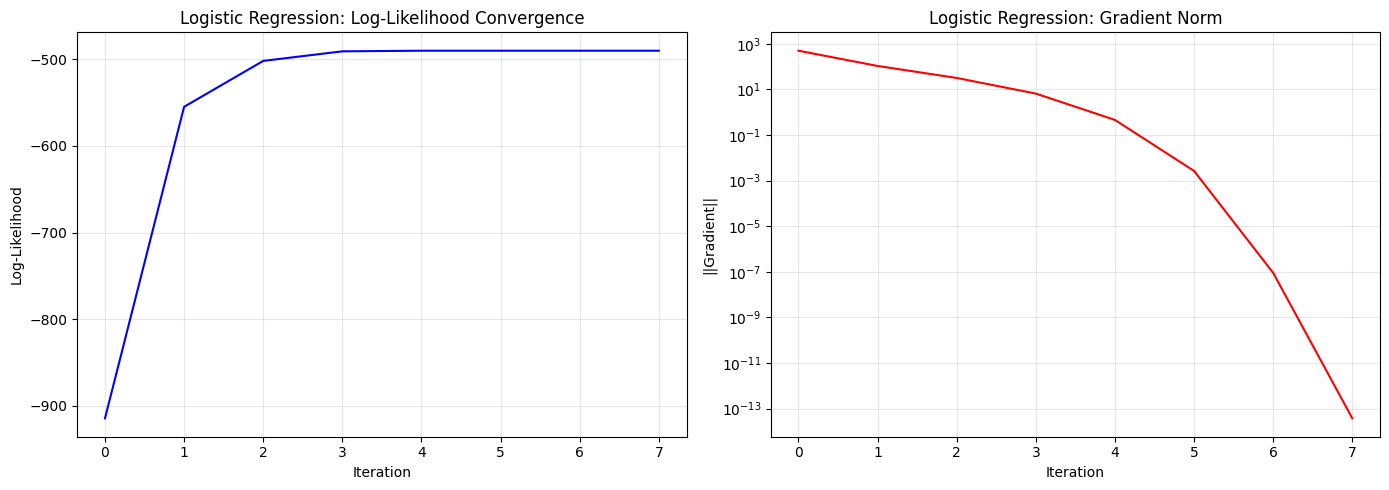

In [14]:
fisher_results_credit_norm = display_fisher_results(beta=beta_fisher_norm,
                                        X=X_scaled, Y=Y,
                                        feature_names=feature_names,
                                        link_type=link_type)
plot_fisher_convergence(history_fisher, title="Logistic Regression")

## MCMC Random Walk Metropolis Hastings 

Execute Metropolis-Hastings MCMC with 15,000 iterations, 3,000 burn-in, and thinning of 10.

In [15]:
mcmc_samples, accept_rate = mh(X_scaled, Y,
                               n_iter=15000, burn_in=3000,
                               rw_sd=0.05, sigma2=20.0,
                               init_beta=None,
                               thin=10, link = link_type)

beta_df = pd.DataFrame(mcmc_samples['beta'], columns=feature_names)
beta_df['log_posterior'] = mcmc_samples['log_posterior']


### MCMC Results

Display acceptance rate and posterior summaries for all coefficients.

In [16]:
print('Accept_rate: ', accept_rate)
mcmc_summary_credit = mcmc_summary(mcmc_samples, feature_names)
print("MCMC Results - Posterior Summary (CreditCard)")
print(mcmc_summary_credit)

Accept_rate:  0.42733333333333334
MCMC Results - Posterior Summary (CreditCard)
     Variable      Mean    Median   Std Dev      2.5%     97.5%
0   Intercept  1.288926  1.284538  0.129986  1.042513  1.543854
1     reports -2.355229 -2.357248  0.168907 -2.681402 -2.008186
2         age -0.122438 -0.117735  0.095862 -0.309056  0.061167
3      income  0.395761  0.396375  0.110499  0.181607  0.600502
4       owner  0.513753  0.508341  0.210768  0.124783  0.935090
5     selfemp -0.706150 -0.710283  0.252964 -1.180642 -0.221872
6  dependents -0.310071 -0.308018  0.083996 -0.477794 -0.140158
7      months  0.030228  0.030604  0.088685 -0.148425  0.202911
8  majorcards  0.192103  0.195918  0.076669  0.042007  0.336343
9      active  0.825192  0.828478  0.111403  0.620377  1.037557


Diagnostic plots for 'income' coefficient: trace plot, posterior distribution, and autocorrelation.

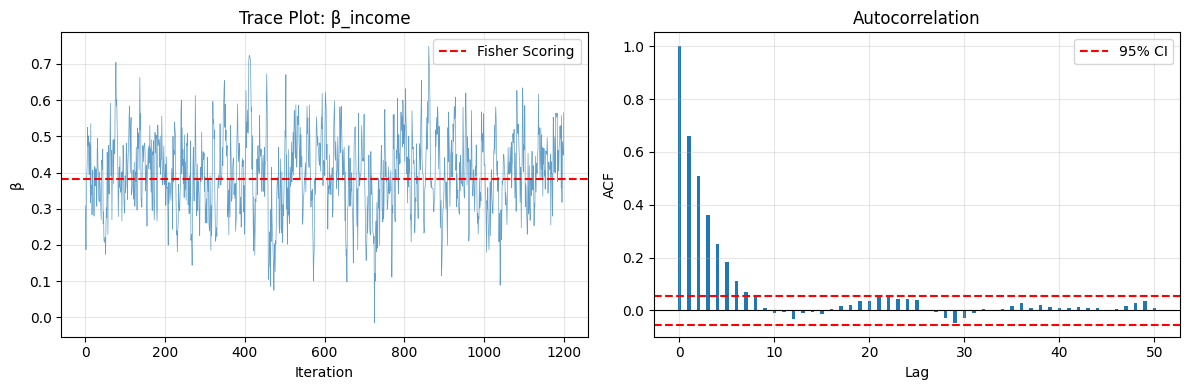

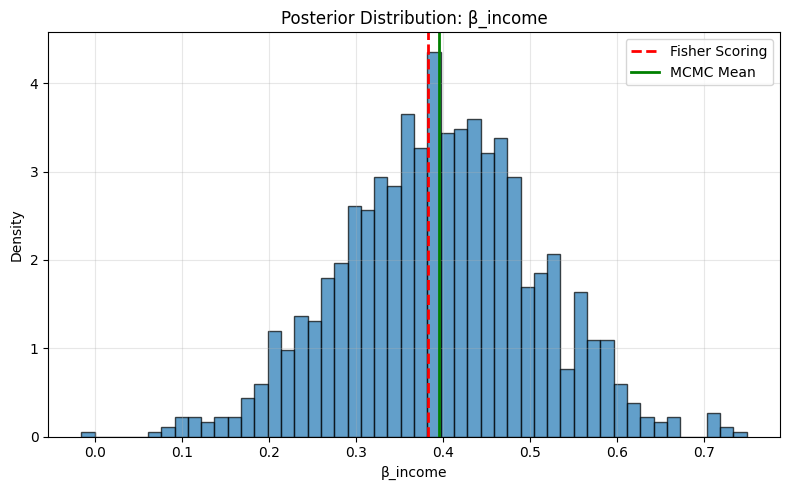

In [17]:
mcmc_trace_acf(mcmc_samples, feature_names, 'income', beta_fisher=beta_fisher_norm, max_lag=50)
mcmc_posterior(mcmc_samples, feature_names, 'income', beta_fisher=beta_fisher_norm)

## Comparison

Compare frequentist (Fisher) and Bayesian (MCMC) coefficient estimates with uncertainty intervals.

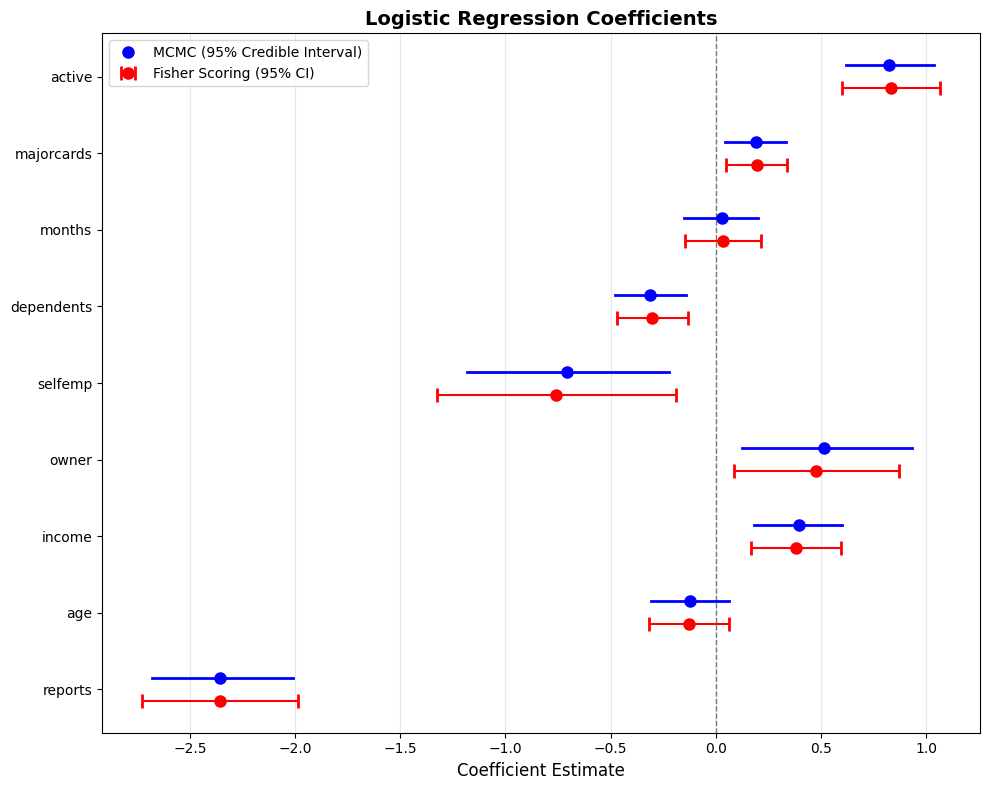

In [18]:
plot_coefficient_comparison(fisher_results_credit_norm, mcmc_summary_credit,
                           title="Logistic Regression Coefficients")
plt.show()

### Top 3 Most Influential Covariates

Identify and interpret the three most influential predictors.

In [19]:
credit_stds = {
    'reports': 1.345267,
    'active': 6.305812,
    'selfemp': 1.0  
}

In [23]:
df_top3 = top_influential_covariates(beta_fisher_norm, feature_names, credit_stds)
df_top3

,Variable,Coef(Std),Coef(Raw),exp(Coef_Raw),Interpretation
0,reports,-2.3565 (std),-1.7517 (raw),0.1735,decreases the mean/odds by 82.65%
1,active,0.8342 (std),0.1323 (raw),1.1414,increases the mean/odds by 14.14%
2,selfemp,-0.7573 (std),-0.7573 (raw),0.4689,decreases the mean/odds by 53.11%


# azcabgptca Dataset 

**Data Loading and Preprocessing**

Load hospital length-of-stay (LOS) dataset and standardize age variable.

In [24]:
hosp = pd.read_csv("azcabgptca.csv") 
# Y
Y_hosp = hosp['los'].astype(int).values

X_hosp_norm = hosp[['died', 'procedure', 'age', 'gender', 'type']].copy()


X_hosp_norm['age'] = X_hosp_norm['age'].astype(float)
# Standardize 'age'
age_mean = X_hosp_norm['age'].mean()
age_std = X_hosp_norm['age'].std(ddof=1)
X_hosp_norm['age'] = (X_hosp_norm['age'] - age_mean) / age_std
# Standardize 'died‘
died_mean = X_hosp_norm['died'].mean()
died_std = X_hosp_norm['died'].std(ddof=1)
X_hosp_norm['died'] = (X_hosp_norm['died'] - died_mean) / died_std

X_hosp_norm = np.column_stack([np.ones(X_hosp_norm.shape[0]), X_hosp_norm.values])

feature_names_h = ['intercept','died', 'procedure', 'age', 'gender', 'type']


In [25]:
print("\n--- azcabgptca Dataset Std ---")
print(hosp.std(ddof=1))


--- azcabgptca Dataset Std ---
died         0.134344
procedure    0.499463
age          4.024198
gender       0.461492
los          5.601206
type         0.498219
dtype: float64


## Run Fisher Scoring 

Run Fisher Scoring with Poisson link function for count data (length of stay).

In [26]:
beta_pois, hist_pois = fisher_scoring(X_hosp_norm, Y_hosp, link="poisson", eps=1e-8, max_iter=100)
se_p, z_p, p_p = fisher_results(beta_pois, X_hosp_norm, link="poisson")


Converged at iteration 14


### Fisher Scoring Results 

Display Poisson regression results and convergence diagnostics.

Fisher Scoring Results - Poisson Regression
    Variable  Coefficient  Std Error    z-value       p-value Signif.
0  intercept     1.282117   0.021938  58.442820  0.000000e+00     ***
1       died    -0.041257   0.008083  -5.104180  3.322317e-07     ***
2  procedure     1.130133   0.019021  59.416393  0.000000e+00     ***
3        age     0.043209   0.008408   5.138791  2.765114e-07     ***
4     gender    -0.106073   0.018206  -5.826390  5.663926e-09     ***
5       type     0.189399   0.016846  11.243168  0.000000e+00     ***


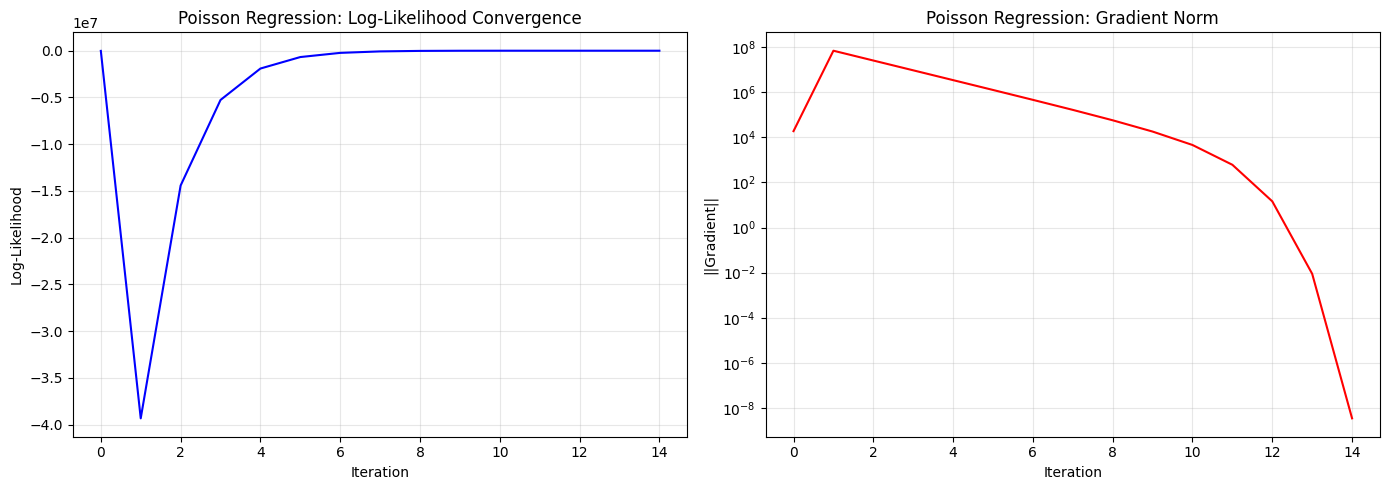

In [27]:

results_pois_norm = display_fisher_results(
    beta=beta_pois,
    X=X_hosp_norm,
    Y=Y_hosp,
    feature_names=feature_names_h,
    link_type="poisson"
)
plot_fisher_convergence(hist_pois, title= 'Poisson Regression')

## MCMC Random Walk Metropolis Hastings 

Run MCMC for Poisson regression with smaller step size (rw_sd=0.01) due to count data sensitivity.

In [28]:
link_pois = 'poisson'
mcmc_hosp , accept_hosp = mh(X_hosp_norm, Y_hosp, n_iter = 15000, burn_in = 3000, 
                             rw_sd=0.01, sigma2=25.0, 
                             init_beta=None,
                             thin = 10, link = link_pois)

beta_hosp = pd.DataFrame(mcmc_hosp['beta'], columns = feature_names_h)
beta_hosp['log_posterior'] = mcmc_hosp['log_posterior']
beta_hosp.head()

,intercept,died,procedure,age,gender,type,log_posterior
0,1.311239,-0.029129,1.122375,0.027797,-0.107082,0.152528,-5214.861072
1,1.327810,-0.036622,1.108052,0.038022,-0.114922,0.144361,-5213.905742
2,1.323630,-0.034389,1.105906,0.039110,-0.115972,0.146155,-5213.962398
3,1.315539,-0.045225,1.101063,0.042243,-0.117891,0.182535,-5210.947205
4,1.320602,-0.044734,1.098890,0.052339,-0.118775,0.175534,-5211.860302


Display MCMC acceptance rate and posterior summaries for hospital data.

In [29]:
print('Accept_rate: ', accept_rate)
mcmc_summary_hosp = mcmc_summary(mcmc_hosp, feature_names_h)
print("MCMC Results - Posterior Summary (Hospital dataset)")
print(mcmc_summary_hosp)

Accept_rate:  0.42733333333333334
MCMC Results - Posterior Summary (Hospital dataset)
    Variable      Mean    Median   Std Dev      2.5%     97.5%
0  intercept  1.285360  1.284788  0.021615  1.243488  1.326906
1       died -0.041344 -0.041192  0.008083 -0.056755 -0.025296
2  procedure  1.128227  1.128692  0.019625  1.088459  1.165832
3        age  0.043278  0.043486  0.008430  0.026034  0.059143
4     gender -0.108392 -0.109126  0.018164 -0.142786 -0.071906
5       type  0.189145  0.189075  0.017755  0.154994  0.225565


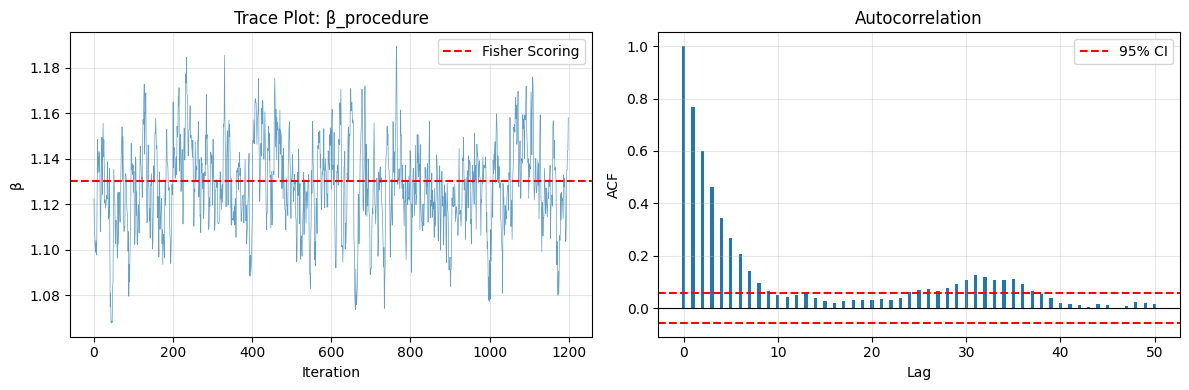

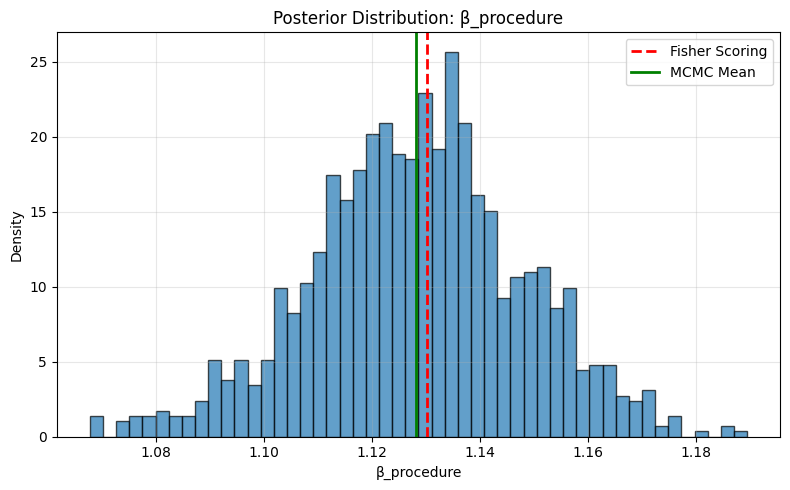

In [30]:
mcmc_trace_acf(mcmc_hosp, feature_names_h, 'procedure', beta_fisher=beta_pois, max_lag=50)
mcmc_posterior(mcmc_hosp, feature_names_h, 'procedure', beta_fisher=beta_pois)

MCMC diagnostics for 'procedure' coefficient.

## Comparison 

Compare Fisher Scoring and MCMC estimates for Poisson regression.

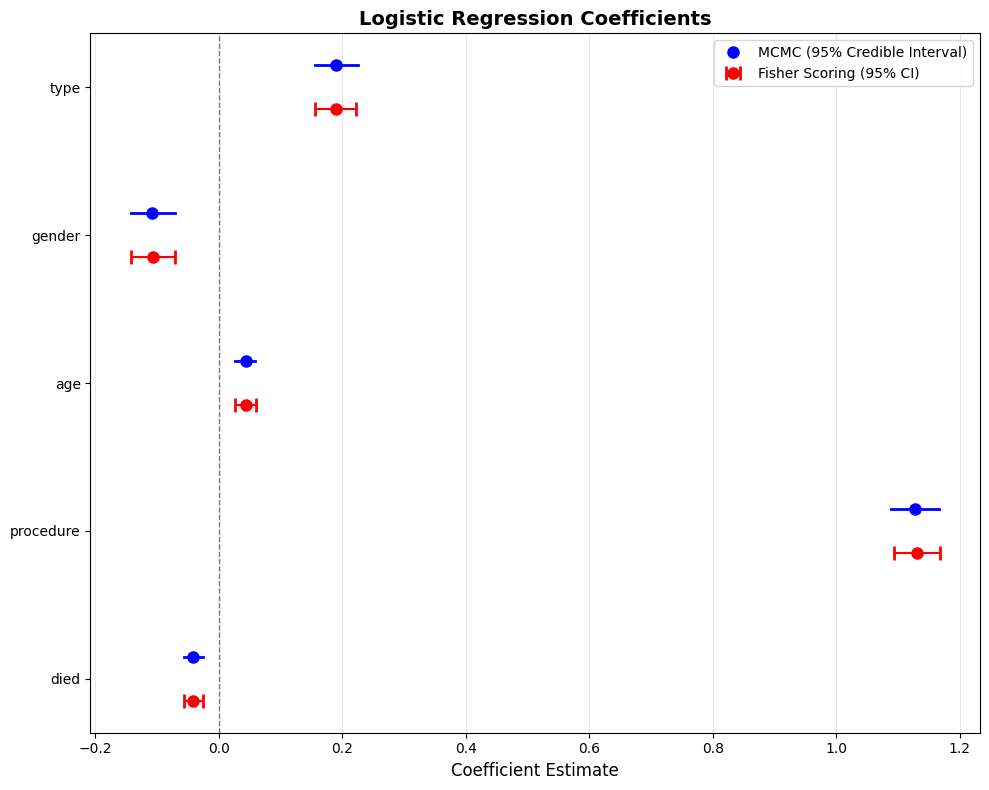

In [31]:
plot_coefficient_comparison(results_pois_norm, mcmc_summary_hosp,
                           title="Logistic Regression Coefficients")
plt.show()

Top 3 influential predictors for hospital length of stay.

In [ ]:
az_stds = { #all binary
    'procedure': 1.0,
    'gender': 1.0,
    'type': 1.0
}

In [35]:
hosp_top3 = top_influential_covariates(beta_pois, feature_names_h, az_stds)
hosp_top3

,Variable,Coef(Std),Coef(Raw),exp(Coef_Raw),Interpretation
0,procedure,1.1301 (std),1.1301 (raw),3.0961,increases the mean/odds by 209.61%
1,type,0.1894 (std),0.1894 (raw),1.2085,increases the mean/odds by 20.85%
2,gender,-0.1061 (std),-0.1061 (raw),0.8994,decreases the mean/odds by 10.06%


# Comparison Tables

Comprehensive comparison of Fisher Scoring (frequentist) and MCMC (Bayesian) results.

In [32]:
def create_comparison_table(fisher_df, mcmc_df, title="Method Comparison"):
    # Extract variable names
    variables = fisher_df['Variable'].values
    
    # Create rows for the table
    fisher_coef_row = fisher_df['Coefficient'].values
    mcmc_mean_row = mcmc_df['Mean'].values
    mcmc_std_row = mcmc_df['Std Dev'].values
    
    # Build the comparison dataframe
    comparison_data = {
        'Method': ['Fisher (Coef)', 'MCMC (Mean)', 'MCMC (Std)']
    }
    
    # Add each variable as a column
    for i, var in enumerate(variables):
        comparison_data[var] = [
            f"{fisher_coef_row[i]:.4f}",
            f"{mcmc_mean_row[i]:.4f}",
            f"{mcmc_std_row[i]:.4f}"
        ]
    
    comparison_df = pd.DataFrame(comparison_data)
    
    print(f"\n{'='*100}")
    print(f"{title:^100}")
    print(f"{'='*100}")
    print(comparison_df.to_string(index=False))
    print(f"{'='*100}\n")
    
    return comparison_df

## Credit Card Dataset - Method Comparison Table

In [33]:
credit_comparison = create_comparison_table(
    fisher_results_credit_norm, 
    mcmc_summary_credit,
    title="Credit Card Dataset: Fisher Scoring vs MCMC"
)


                            Credit Card Dataset: Fisher Scoring vs MCMC                             
       Method Intercept reports     age income  owner selfemp dependents months majorcards active
Fisher (Coef)    1.2998 -2.3565 -0.1269 0.3833 0.4783 -0.7573    -0.3023 0.0338     0.1954 0.8342
  MCMC (Mean)    1.2889 -2.3552 -0.1224 0.3958 0.5138 -0.7061    -0.3101 0.0302     0.1921 0.8252
   MCMC (Std)    0.1300  0.1689  0.0959 0.1105 0.2108  0.2530     0.0840 0.0887     0.0767 0.1114



## Hospital Dataset - Method Comparison Table

In [34]:
hospital_comparison = create_comparison_table(
    results_pois_norm, 
    mcmc_summary_hosp,
    title="Hospital Dataset (Poisson): Fisher Scoring vs MCMC"
)


                         Hospital Dataset (Poisson): Fisher Scoring vs MCMC                         
       Method intercept    died procedure    age  gender   type
Fisher (Coef)    1.2821 -0.0413    1.1301 0.0432 -0.1061 0.1894
  MCMC (Mean)    1.2854 -0.0413    1.1282 0.0433 -0.1084 0.1891
   MCMC (Std)    0.0216  0.0081    0.0196 0.0084  0.0182 0.0178

